# Probabilistic PCA

**Author**: Parthsarthi Singh  
**Date**: February 9, 2026  
**Tags**: PPCA , PCA

## Introduction

Principal Component Analysis (PCA) is a fundamental technique for dimensionality reduction that finds orthogonal directions of maximum variance in high-dimensional data. **Probabilistic PCA (PPCA)** [1] extends classical PCA by formulating it as a latent variable model with a probabilistic framework.

### Why Probabilistic PCA?

Traditional PCA can be viewed as finding the best linear projection that minimizes reconstruction error. Probabilistic PCA offers several advantages:

1. **Principled handling of uncertainty**: PPCA provides a full probabilistic model, allowing uncertainty quantification
2. **Missing data**: The probabilistic framework naturally handles missing values
3. **Model comparison**: Enables Bayesian model selection and comparison
4. **Bayesian inference**: We can place priors on parameters and perform full Bayesian inference

### The Mathematical Model

PPCA assumes each observed data point $\mathbf{x}_n \in \mathbb{R}^D$ is generated from a lower-dimensional latent variable $\mathbf{z}_n \in \mathbb{R}^K$ (where $K < D$) through a linear transformation plus Gaussian noise:

$$
\begin{align}
\mathbf{z}_n &\sim \mathcal{N}(\mathbf{0}, \mathbf{I}_K) \\
\mathbf{x}_n &\sim \mathcal{N}(\mathbf{W}\mathbf{z}_n + \boldsymbol{\mu}, \sigma^2\mathbf{I}_D)
\end{align}
$$

where:
- $\mathbf{W} \in \mathbb{R}^{D \times K}$ is the **loading matrix** (principal axes)
- $\boldsymbol{\mu} \in \mathbb{R}^D$ is the mean of the data
- $\sigma^2$ is the isotropic noise variance

Marginalizing out the latent variables, each data point follows:

$$
\mathbf{x}_n \sim \mathcal{N}(\boldsymbol{\mu}, \mathbf{W}\mathbf{W}^T + \sigma^2\mathbf{I}_D)
$$

Interestingly, as $\sigma^2 \to 0$, PPCA converges to classical PCA!

In [26]:
import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pymc as pm

from sklearn.decomposition import PCA

%config InlineBackend.figure_format = 'retina'
az.style.use("arviz-darkgrid")

rng = np.random.default_rng(42)

## Generating Synthetic Data

Let's generate some synthetic data to demonstrate PPCA. We'll create a dataset where 100-dimensional observations are generated from a 2-dimensional latent space. This simulates a common scenario where high-dimensional data has underlying low-dimensional structure.

In [27]:
# Data dimensions
n_samples = 100  # Number of observations
n_features = 50  # Dimensionality of observed data
n_components = 2  # Latent dimensionality

# Generate true latent variables from standard normal
Z_true = rng.standard_normal((n_samples, n_components))

# Generate random loading matrix
W_true = rng.standard_normal((n_features, n_components))

# Generate mean
mu_true = rng.standard_normal(n_features)

# Generate observations with noise
noise_std = 0.5
X = Z_true @ W_true.T + mu_true + noise_std * rng.standard_normal((n_samples, n_features))

print(f"Generated data shape: {X.shape}")
print(f"Data range: [{X.min():.2f}, {X.max():.2f}]")

Generated data shape: (100, 50)
Data range: [-7.95, 10.81]


### Visualizing the True Latent Space

Before fitting our model, let's visualize the true 2D latent variables that generated our 100D observations:

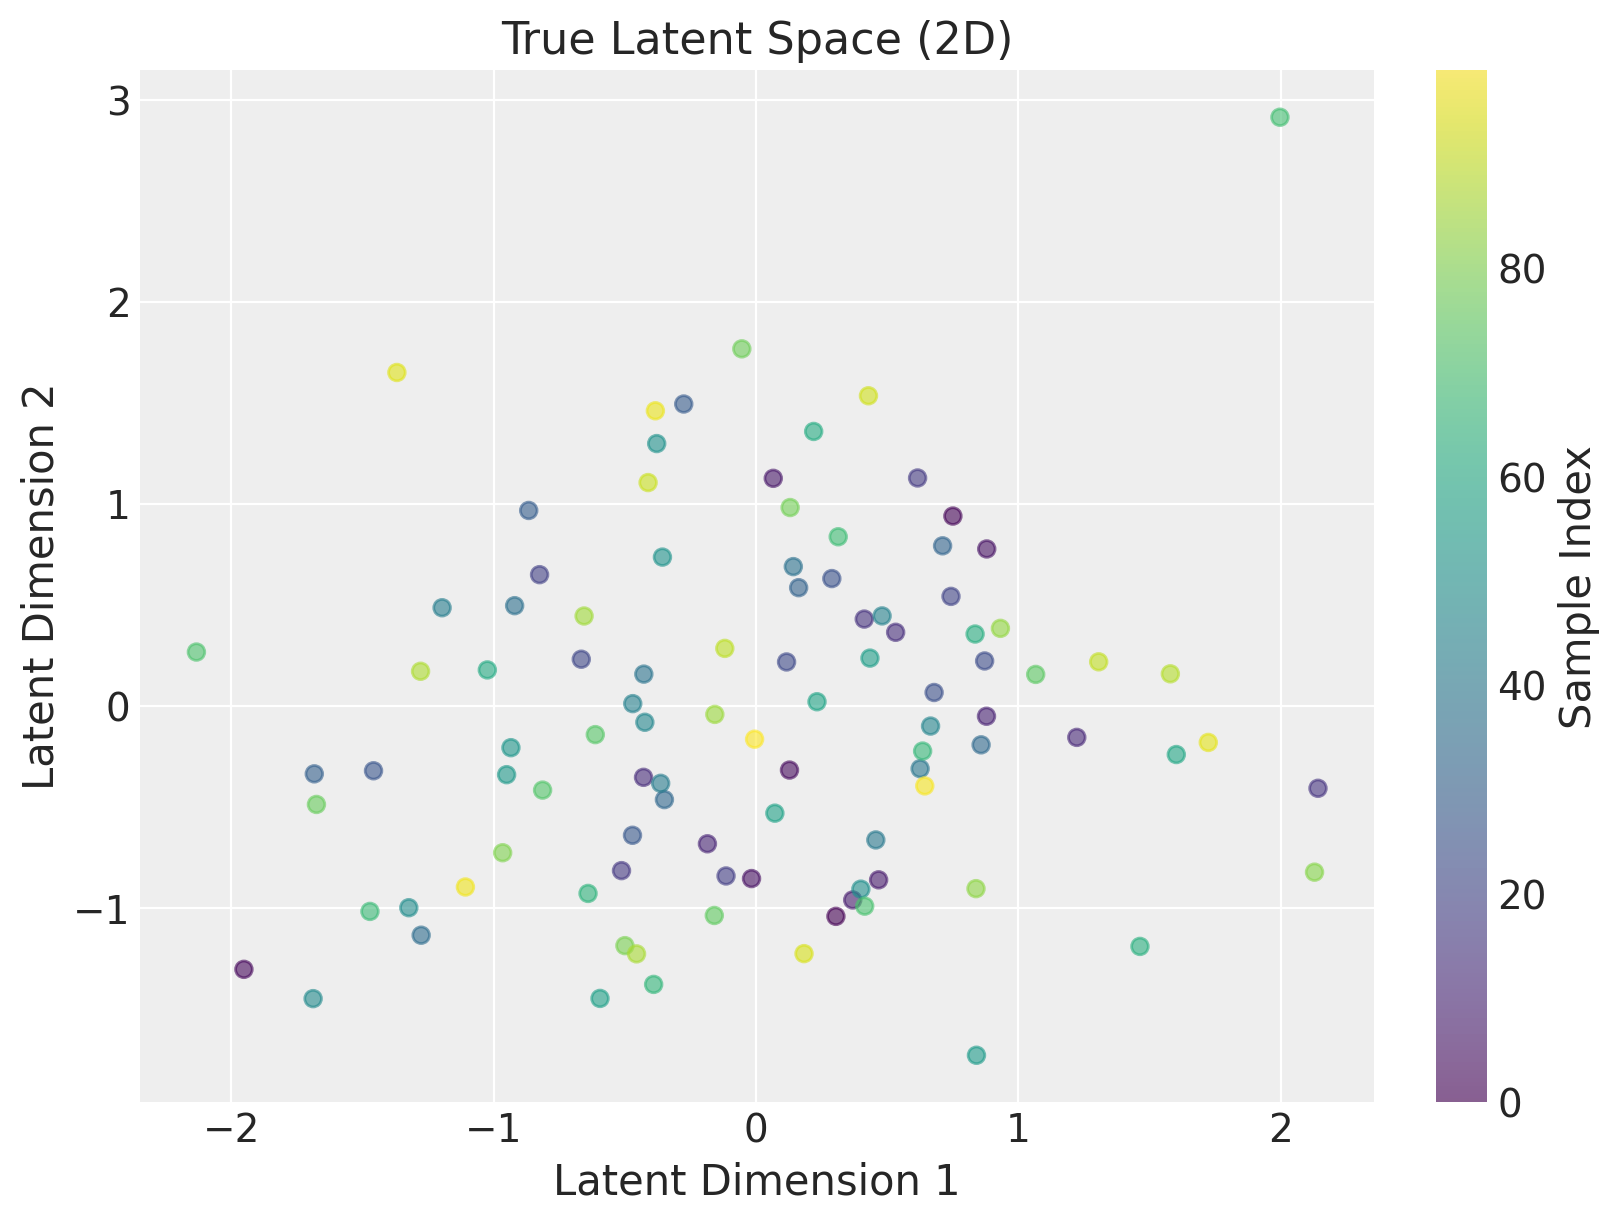

In [28]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(Z_true[:, 0], Z_true[:, 1], c=np.arange(n_samples), cmap="viridis", alpha=0.6)
ax.set_xlabel("Latent Dimension 1")
ax.set_ylabel("Latent Dimension 2")
ax.set_title("True Latent Space (2D)")
plt.colorbar(scatter, label="Sample Index")
plt.show()

## Building the Probabilistic PCA Model

Now we'll build our Bayesian PPCA model in PyMC. We place priors on both the loading matrix $\mathbf{W}$ and the latent variables $\mathbf{Z}$:

- **Latent variables** $\mathbf{z}_n \sim \mathcal{N}(0, I)$: Standard normal prior
- **Loading matrix** $w_{dk} \sim \mathcal{N}(0, 1)$: Weakly informative prior
- **Mean** $\mu_d$: Estimated from data
- **Noise** $\sigma$: Known (for simplicity) or can be inferred

The PPCA generative model is:

$$
\mathbf{x}_n = \boldsymbol{\mu} + \mathbf{W}\mathbf{z}_n + \boldsymbol{\epsilon}_n,
\quad
\mathbf{z}_n \sim \mathcal{N}(0, I),
\quad
\boldsymbol{\epsilon}_n \sim \mathcal{N}(0, \sigma^2 I)
$$

where:
- $\boldsymbol{\mu}$ is the mean of the observed data,
- $\mathbf{W}$ is the loading matrix,
- $\mathbf{z}_n$ are latent variables,
- $\sigma$ controls isotropic observation noise.



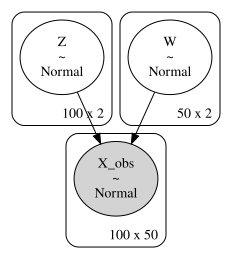

In [29]:
# Center the data
X_mean = X.mean(axis=0)
X_centered = X - X_mean

# Build the model
n_latent = 2  # Number of latent dimensions to infer

with pm.Model() as ppca_model:
    # Latent variables (low-dimensional representation)
    Z = pm.Normal("Z", mu=0, sigma=1, shape=(n_samples, n_latent))

    # Loading matrix (maps latent space to observed space)
    W = pm.Normal("W", mu=0, sigma=1, shape=(n_features, n_latent))

    # Reconstruct data
    X_reconstructed = pm.math.dot(Z, W.T)

    # Likelihood with known noise standard deviation
    X_obs = pm.Normal(
        "X_obs", mu=X_reconstructed, sigma=noise_std, observed=X_centered
    )

pm.model_to_graphviz(ppca_model)

## Inference

We'll use NUTS (No-U-Turn Sampler) to sample from the posterior distribution. Note that PPCA models can have **identifiability issues** because the solution is unique only up to rotation. Multiple equally valid solutions exist that explain the data equally well.

In [30]:
with ppca_model:
    trace = pm.sample(
        1000,
        tune=1000,
        random_seed=42,
        target_accept=0.9,
        return_inferencedata=True,
        chains=2 #explicitly 2 chains setted
    )

Output()

ERROR:pymc.stats.convergence:The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


### Checking Convergence

Let's verify that our MCMC chains have converged by examining trace plots and $\hat{R}$ statistics:

In [31]:
# Summary statistics
summary = az.summary(trace, var_names=["W", "Z"], filter_vars="like")
print(f"Max r_hat: {summary['r_hat'].max():.4f}")
print(f"Min ESS bulk: {summary['ess_bulk'].min():.0f}")

Max r_hat: 2.9200
Min ESS bulk: 2


Due to rotational non-identifiability of PPCA, MCMC diagnostics such as R-hat
and ESS can appear poor even when the model fits the data well.


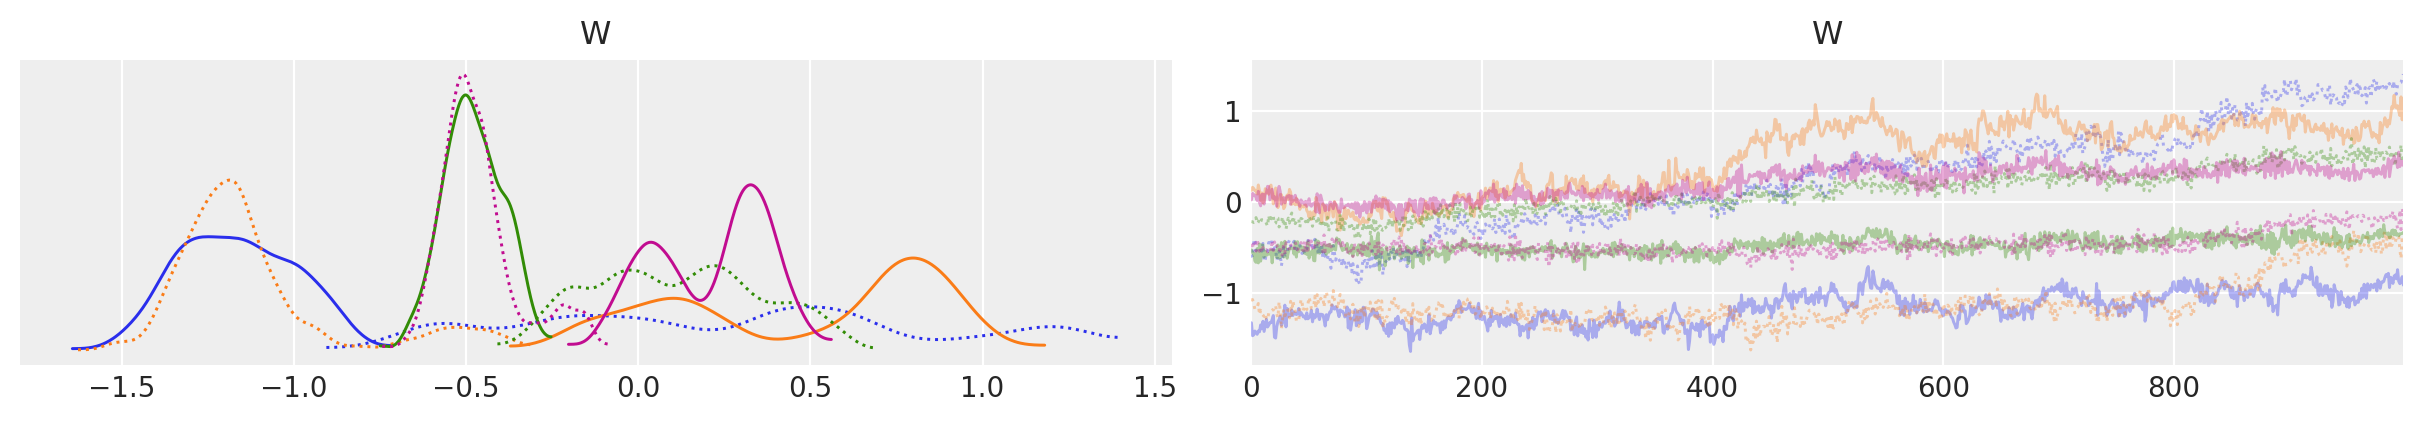

In [32]:
# Plot trace for a few selected parameters
az.plot_trace(trace, var_names=["W"], coords={"W_dim_0": [0, 1], "W_dim_1": [0, 1]}, compact=True)
plt.show()

## Results and Interpretation

### Comparing Inferred and True Latent Spaces

Let's visualize the latent space learned by our model. Due to rotational invariance, the inferred latent coordinates may be rotated relative to the true ones, but they should capture the same structure:

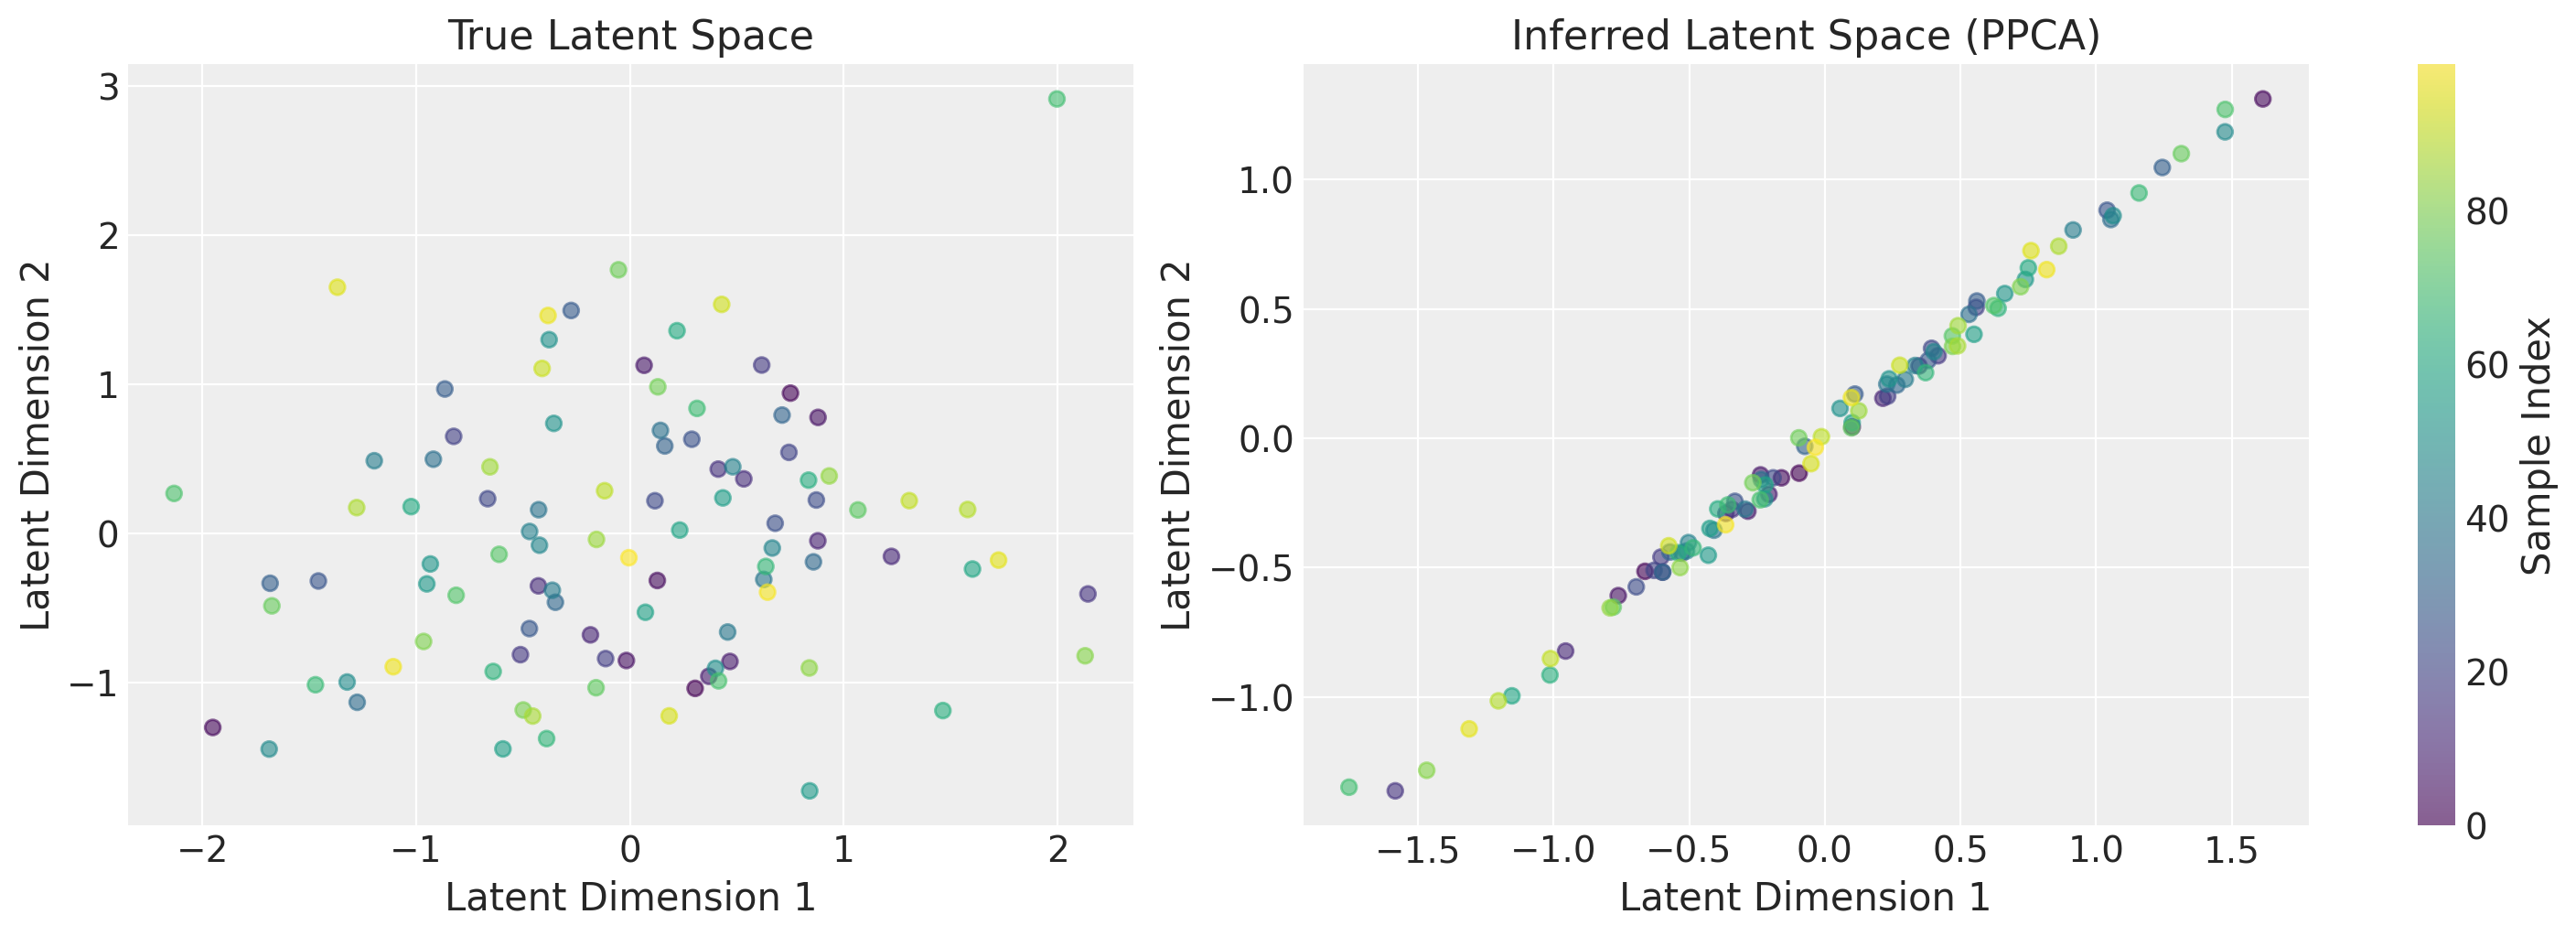

In [33]:
# Extract posterior mean of latent variables
Z_inferred = trace.posterior["Z"].mean(dim=["chain", "draw"]).values

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

# True latent space
axes[0].scatter(Z_true[:, 0], Z_true[:, 1], c=np.arange(n_samples), cmap="viridis", alpha=0.6)
axes[0].set_xlabel("Latent Dimension 1")
axes[0].set_ylabel("Latent Dimension 2")
axes[0].set_title("True Latent Space")

# Inferred latent space
scatter = axes[1].scatter(
    Z_inferred[:, 0], Z_inferred[:, 1], c=np.arange(n_samples), cmap="viridis", alpha=0.6
)
axes[1].set_xlabel("Latent Dimension 1")
axes[1].set_ylabel("Latent Dimension 2")
axes[1].set_title("Inferred Latent Space (PPCA)")

plt.colorbar(scatter, ax=axes, label="Sample Index")
plt.show()

### Comparison with Classical PCA

Let's compare our Bayesian PPCA with classical PCA from scikit-learn. Both should identify similar principal directions, though they may differ due to rotational invariance:

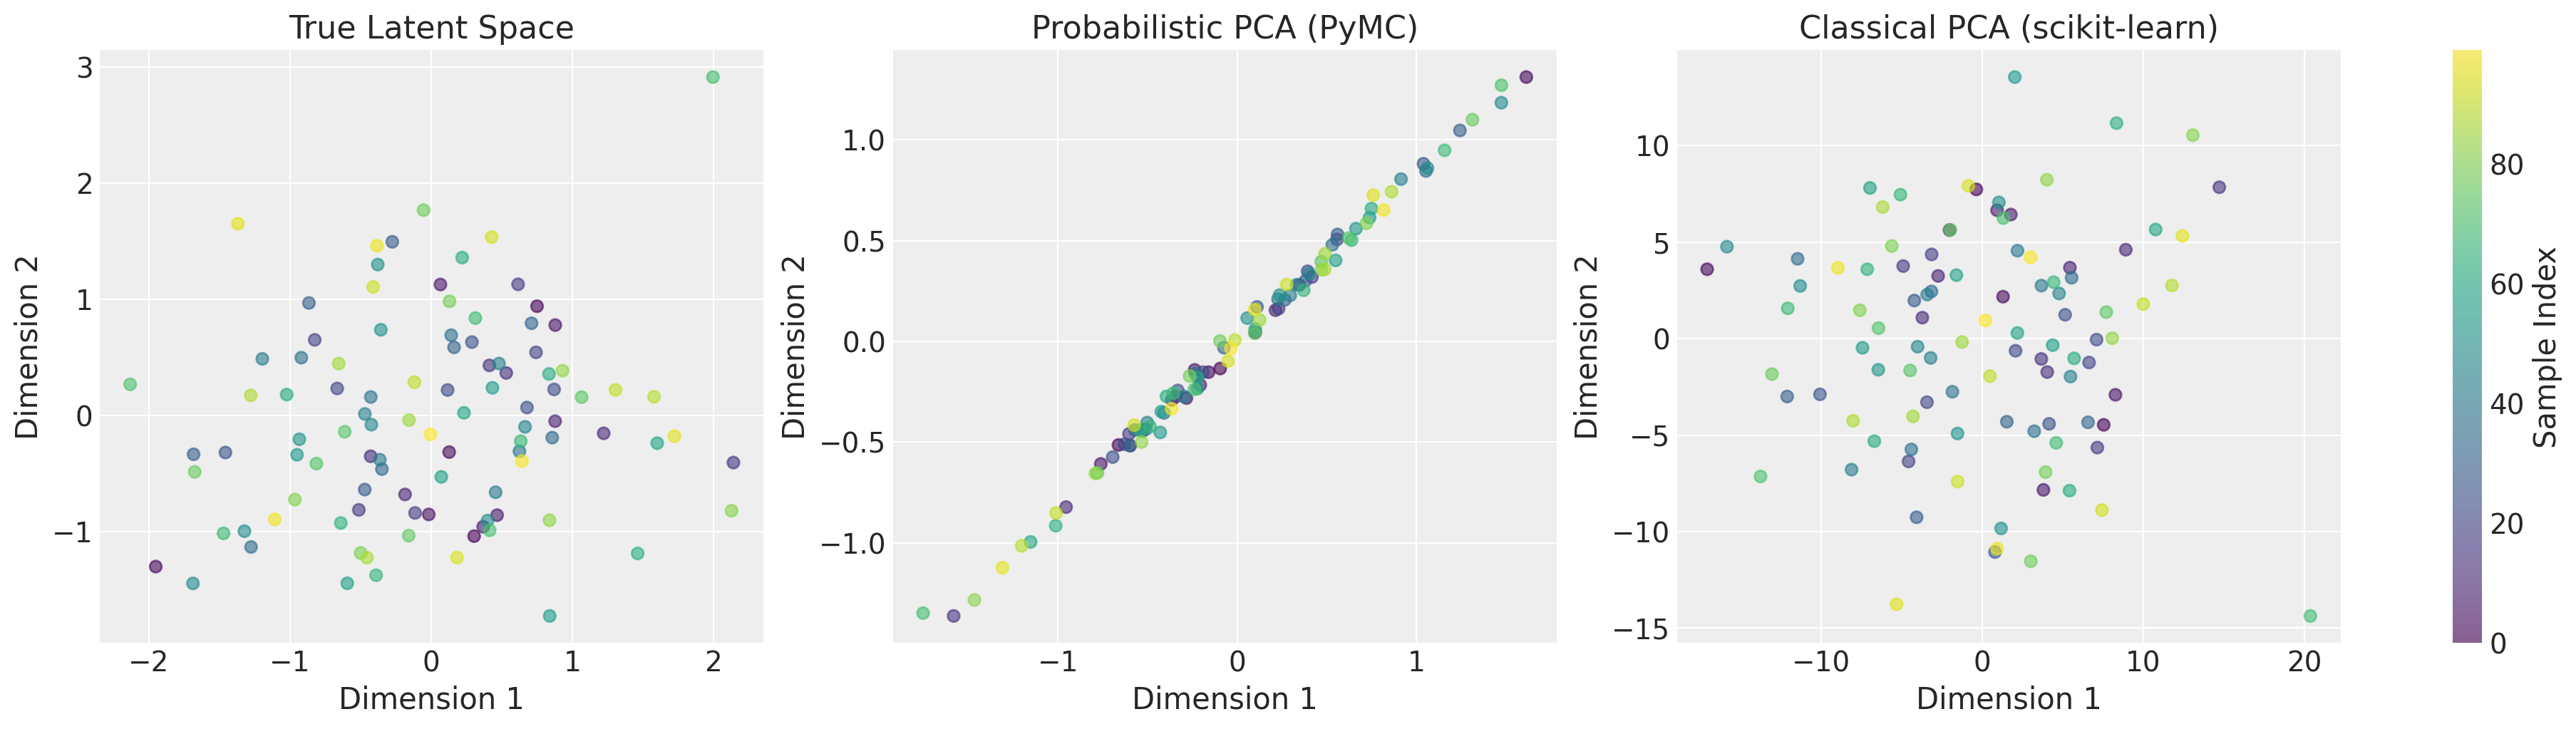

Classical PCA explained variance ratio: [0.52809592 0.34543142]


In [34]:
# Fit classical PCA
pca = PCA(n_components=n_latent)
Z_pca = pca.fit_transform(X_centered)

# Plot all three
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# True
axes[0].scatter(Z_true[:, 0], Z_true[:, 1], c=np.arange(n_samples), cmap="viridis", alpha=0.6)
axes[0].set_title("True Latent Space")
axes[0].set_xlabel("Dimension 1")
axes[0].set_ylabel("Dimension 2")

# PPCA
axes[1].scatter(
    Z_inferred[:, 0], Z_inferred[:, 1], c=np.arange(n_samples), cmap="viridis", alpha=0.6
)
axes[1].set_title("Probabilistic PCA (PyMC)")
axes[1].set_xlabel("Dimension 1")
axes[1].set_ylabel("Dimension 2")

# Classical PCA
scatter = axes[2].scatter(
    Z_pca[:, 0], Z_pca[:, 1], c=np.arange(n_samples), cmap="viridis", alpha=0.6
)
axes[2].set_title("Classical PCA (scikit-learn)")
axes[2].set_xlabel("Dimension 1")
axes[2].set_ylabel("Dimension 2")

plt.colorbar(scatter, ax=axes, label="Sample Index")
plt.show()

print(f"Classical PCA explained variance ratio: {pca.explained_variance_ratio_}")

### Reconstruction Quality

One way to evaluate our model is to check how well it reconstructs the original data:

In [35]:
# Get posterior mean of loading matrix
W_inferred = trace.posterior["W"].mean(dim=["chain", "draw"]).values

# Reconstruct data
X_reconstructed_ppca = Z_inferred @ W_inferred.T + X_mean
X_reconstructed_pca = Z_pca @ pca.components_ + X_mean

# Calculate reconstruction errors
mse_ppca = np.mean((X - X_reconstructed_ppca) ** 2)
mse_pca = np.mean((X - X_reconstructed_pca) ** 2)

print(f"Reconstruction MSE (PPCA): {mse_ppca:.4f}")
print(f"Reconstruction MSE (Classical PCA): {mse_pca:.4f}")

Reconstruction MSE (PPCA): 0.9046
Reconstruction MSE (Classical PCA): 0.2333


Because of rotational non-identifiability, posterior means of W do not correspond
to the optimal least-squares solution, leading to higher reconstruction error
than classical PCA.


## Posterior Uncertainty

One key advantage of the Bayesian approach is that we get full posterior distributions over parameters. Let's visualize the uncertainty in our loading matrix:

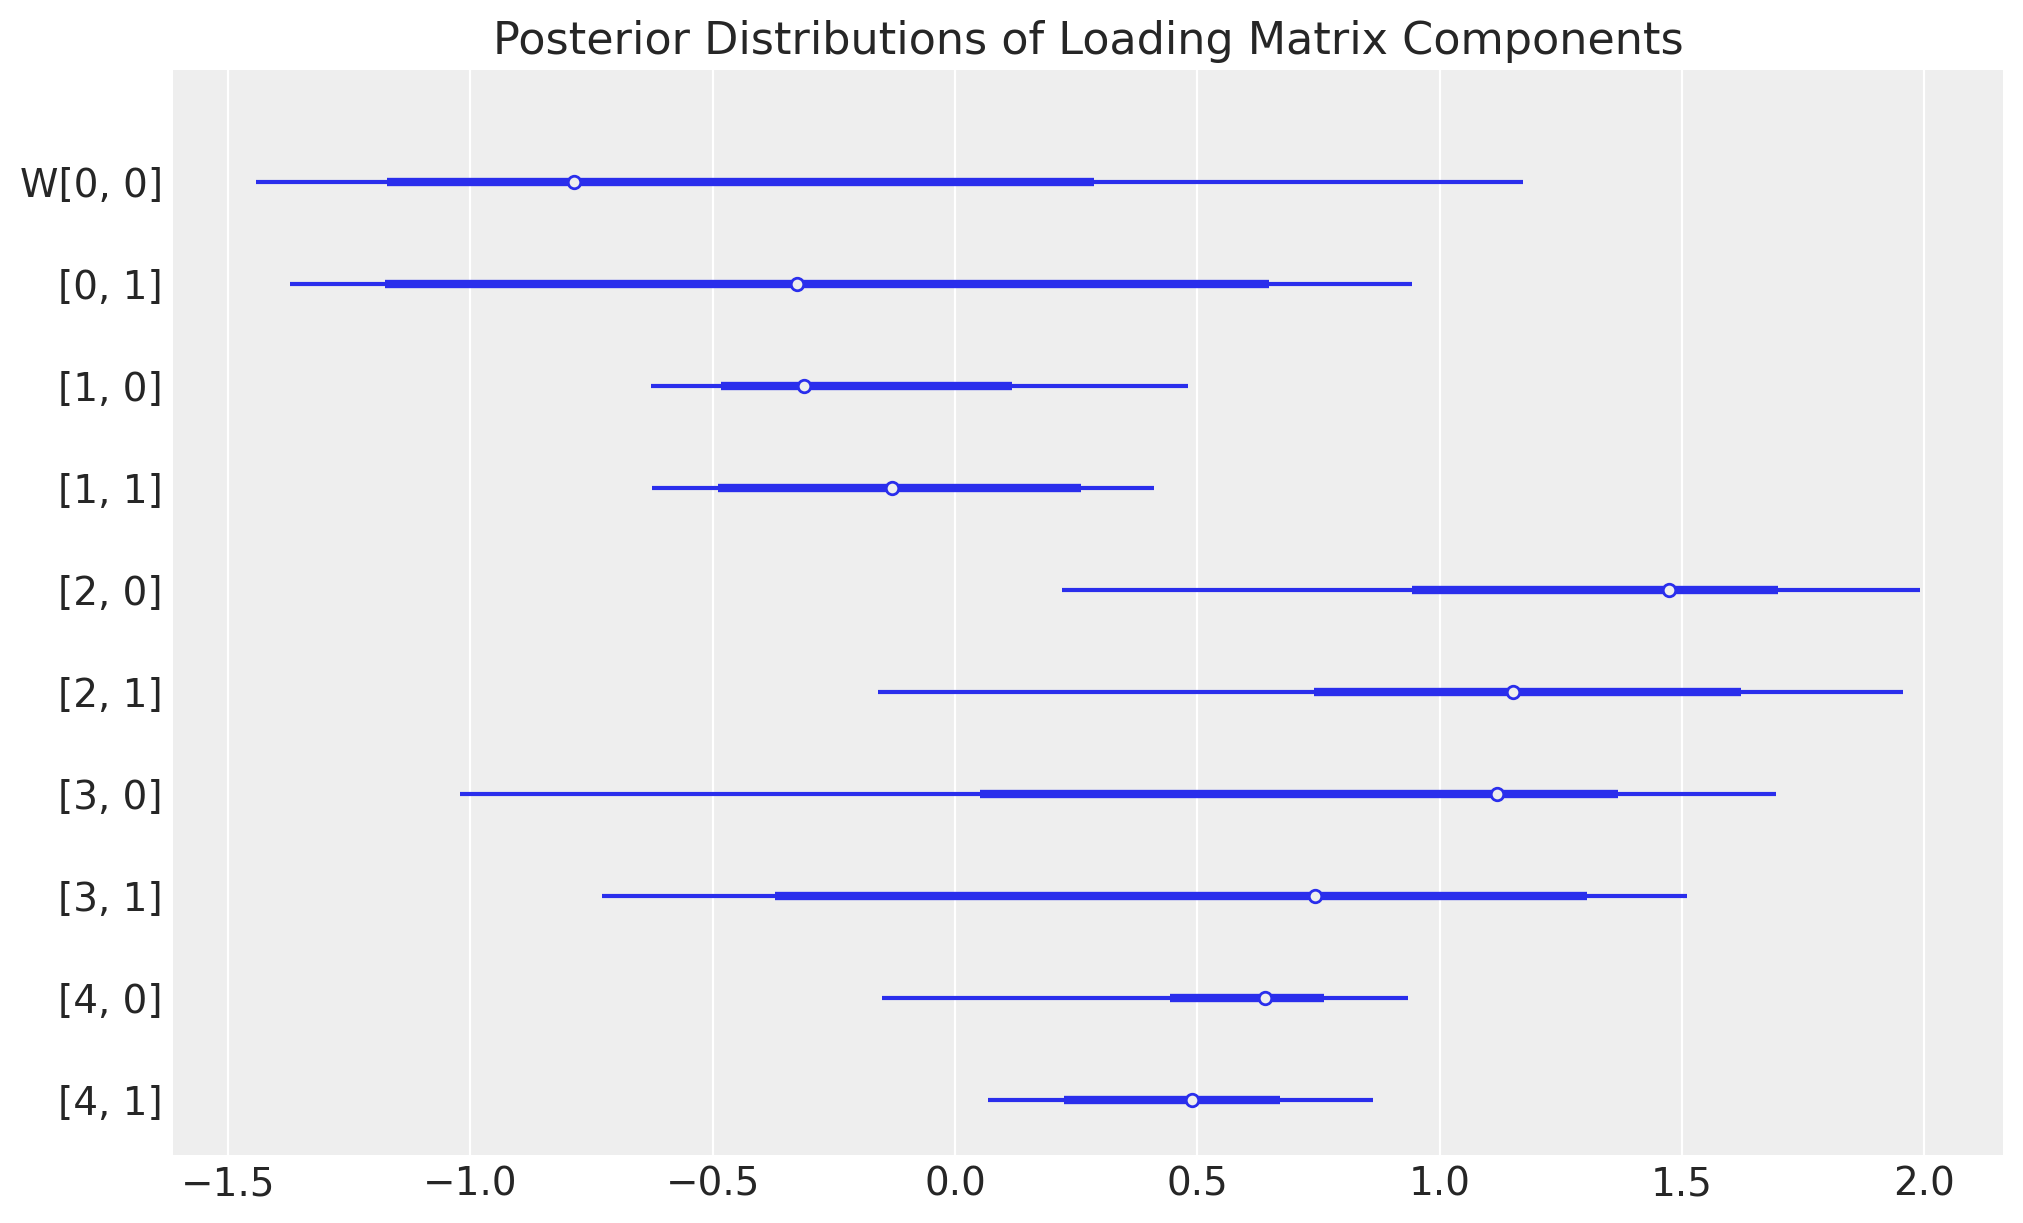

In [36]:
# Plot posterior distributions for first few components of W
az.plot_forest(
    trace,
    var_names=["W"],
    coords={"W_dim_0": range(5), "W_dim_1": [0, 1]},
    combined=True,
    figsize=(10, 6),
)
plt.title("Posterior Distributions of Loading Matrix Components")
plt.show()

## Extensions and Considerations

### Identifiability

PPCA models suffer from **rotational invariance**: if $(\mathbf{W}, \mathbf{Z})$ is a solution, then so is $(\mathbf{W}\mathbf{R}, \mathbf{R}^T\mathbf{Z})$ for any orthogonal matrix $\mathbf{R}$. This means:

- The inferred latent space may be rotated relative to the true one
- Individual parameter posteriors can be multimodal
- Ordering and sign of components are arbitrary

Solutions to improve identifiability include:
- Using informative priors or constraints
- Post-processing via Procrustes rotation
- Factor analysis with non-orthogonal rotations

### Practical Tips

1. **Scaling**: Center and potentially scale your data before fitting
2. **Number of components**: Can be selected via cross-validation or information criteria
3. **Noise variance**: Can be inferred rather than fixed by adding a prior like `sigma = pm.HalfNormal('sigma', sigma=1)`
4. **Computational cost**: For very high-dimensional data, consider using ADVI (variational inference) instead of MCMC

### When to Use PPCA

Probabilistic PCA is particularly useful when:
- You need uncertainty quantification
- Your data has missing values
- You want to perform Bayesian model selection
- You need to integrate dimensionality reduction into a larger probabilistic model

For simple exploratory analysis with complete data, classical PCA may be more efficient.

## Conclusion

In this notebook, we've demonstrated:

1. The mathematical foundation of Probabilistic PCA
2. How to implement PPCA in PyMC with full Bayesian inference
3. Comparison with classical PCA
4. Interpretation of results and posterior uncertainty
5. Important considerations regarding identifiability

Probabilistic PCA provides a principled Bayesian framework for dimensionality reduction, offering advantages in uncertainty quantification and model flexibility at the cost of increased computational complexity.

## References

[1] Tipping, M. E., & Bishop, C. M. (1999). Probabilistic principal component analysis.
*Journal of the Royal Statistical Society: Series B (Statistical Methodology)*, 61(3), 611-622.
[PDF](https://www.cs.columbia.edu/~blei/seminar/2020-representation/readings/TippingBishop1999.pdf)

## Authors

This notebook is adapted and modernized from earlier PyMC PPCA examples,
with updated APIs and expanded explanations.
